In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mirichoi0218/insurance")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'insurance' dataset.
Path to dataset files: /kaggle/input/insurance


In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv(f"{path}/insurance.csv")

# Display the first few rows of the dataset
print(data.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
# Build the model 
data["smoker"] , data["age"]

(0       yes
 1        no
 2        no
 3        no
 4        no
        ... 
 1333     no
 1334     no
 1335     no
 1336     no
 1337    yes
 Name: smoker, Length: 1338, dtype: object,
 0       19
 1       18
 2       28
 3       33
 4       32
         ..
 1333    50
 1334    18
 1335    18
 1336    21
 1337    61
 Name: age, Length: 1338, dtype: int64)

In [4]:
# One-hot encode categorical variables
data_encoded = pd.get_dummies(data)
data_encoded.head()

,age,bmi,children,charges,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,True,False,False,True,False,False,False,True
1,18,33.770,1,1725.55230,False,True,True,False,False,False,True,False
2,28,33.000,3,4449.46200,False,True,True,False,False,False,True,False
3,33,22.705,0,21984.47061,False,True,True,False,False,True,False,False
4,32,28.880,0,3866.85520,False,True,True,False,False,True,False,False


In [5]:
# Create X & y values (fetures and labels)
X = data_encoded.drop("charges" , axis=1)
y = data_encoded["charges"]

# Create training and test sets
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)
len(X_train) , len(X_test) , len(y_train) , len(y_test)
 

(1070, 268, 1070, 268)

In [6]:
# Build a neural network model
import tensorflow as tf

tf.random.set_seed(42)

# Create the model 
data_model = tf.keras.Sequential([
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
data_model.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.SGD(),
    metrics=["mae"]
)

# Fit the model 
data_model.fit(X_train , y_train , epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 10180.0312 - mae: 10180.0312   
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7663.8506 - mae: 7663.8506
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7550.1689 - mae: 7550.1689 
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7479.2798 - mae: 7479.2798 
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7499.1460 - mae: 7499.1460 
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7325.7676 - mae: 7325.7676 
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7666.7119 - mae: 7666.7119 
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7900.6621 - mae: 7900.6621 
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7314.8677 - mae: 7314.8677 
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7495.6245 - mae: 7495.6245 
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7397.5854 - mae: 7397.5854 
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━

In [7]:
# Check the results on the test data
data_model.evaluate(X_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8001.6182 - mae: 8001.6182  


[7964.978515625, 7964.978515625]

In [8]:
y_train.median() , y_train.mean()

(9575.4421, np.float64(13346.089736364485))

It looks like our model isn't performing too well ...
Let's improve it !

In [9]:
# Create the model improved version 1
data_model_improved1 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model
data_model_improved1.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

# Fit the model
data_model_improved1.fit(X_train , y_train , epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13276.1885 - mae: 13276.1885
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13149.1387 - mae: 13149.1387
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12897.3125 - mae: 12897.3125
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12382.6895 - mae: 12382.6895
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11450.6221 - mae: 11450.6221
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 10090.4824 - mae: 10090.4824
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8633.5225 - mae: 8633.5225
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7644.3179 - mae: 7644.3179
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7411.9678 - mae: 7411.9678
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7376.2856 - mae: 7376.2856
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7355.3965 - mae: 7355.3965
Epoch 12/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
data_model_improved1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5079.9116 - mae: 5079.9116  


[4927.712890625, 4927.712890625]

In [11]:
# Create the model improved version 1
data_model_improved2 = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(50),
    tf.keras.layers.Dense(1)
])

# Compile the model
data_model_improved2.compile(
    loss=tf.keras.losses.mae,
    optimizer=tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

# Fit the model
history = data_model_improved2.fit(X_train , y_train , epochs=300)

Epoch 1/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 13222.7324 - mae: 13222.7324
Epoch 2/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12855.2373 - mae: 12855.2373 
Epoch 3/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11828.7305 - mae: 11828.7305
Epoch 4/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9750.3750 - mae: 9750.3750  
Epoch 5/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 7683.0181 - mae: 7683.0181
Epoch 6/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7329.7383 - mae: 7329.7383 
Epoch 7/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7294.3271 - mae: 7294.3271
Epoch 8/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7258.2539 - mae: 7258.2539
Epoch 9/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7222.7764 - mae: 7222.7764
Epoch 10/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7186.3926 - mae: 7186.3926
Epoch 11/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7149.1040 - mae: 7149.1040
Epoch 12/300
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s

In [12]:
data_model_improved2.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3212.7651 - mae: 3212.7651  


[3168.8984375, 3168.8984375]

In [13]:
data_model_improved1.evaluate(X_test, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5079.9116 - mae: 5079.9116 


[4927.712890625, 4927.712890625]

In [14]:
data_model.evaluate(X_test , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8001.6182 - mae: 8001.6182 


[7964.978515625, 7964.978515625]

Text(0.5, 0, 'epochs')

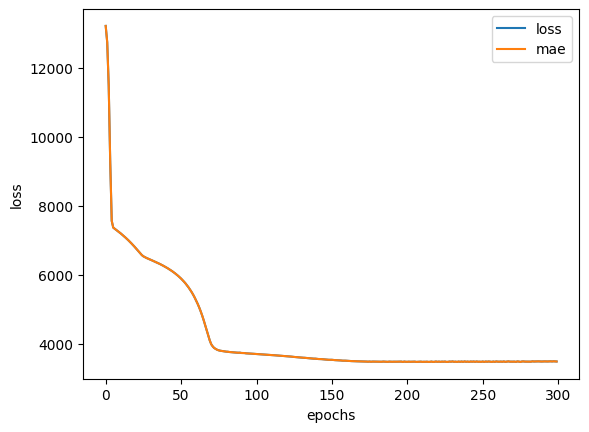

In [15]:
import matplotlib.pyplot as plt
# Plot history (also know as a loss curve or a training curve)
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epochs")


### Preprocessing data (normalization and standardization)

In terms of scaling values , neural networks tend to prefer normalization . 

If you're not sure on which to use , you could try both and see which performs better . 

In [18]:
X_train

,age,bmi,children,sex_female,sex_male,smoker_no,smoker_yes,region_northeast,region_northwest,region_southeast,region_southwest
560,46,19.950,2,True,False,True,False,False,True,False,False
1285,47,24.320,0,True,False,True,False,True,False,False,False
1142,52,24.860,0,True,False,True,False,False,False,True,False
969,39,34.320,5,True,False,True,False,False,False,True,False
486,54,21.470,3,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...
1095,18,31.350,4,True,False,True,False,True,False,False,False
1130,39,23.870,5,True,False,True,False,False,False,True,False
1294,58,25.175,0,False,True,True,False,True,False,False,False
860,37,47.600,2,True,False,False,True,False,False,False,True


<Axes: ylabel='Frequency'>

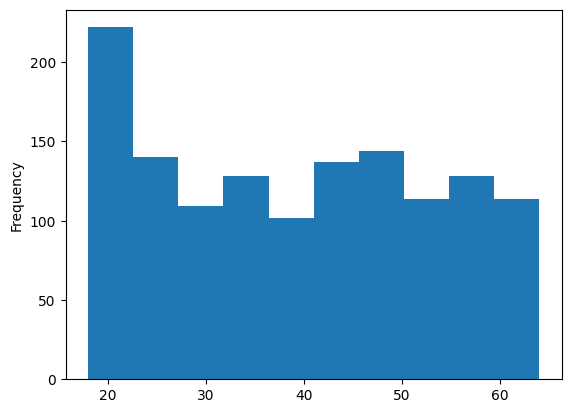

In [20]:
X['age'].plot(kind='hist')

<Axes: ylabel='Frequency'>

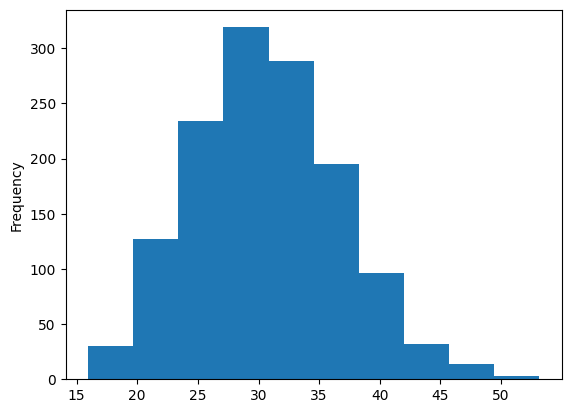

In [21]:
X["bmi"].plot(kind='hist')

<Axes: xlabel='children'>

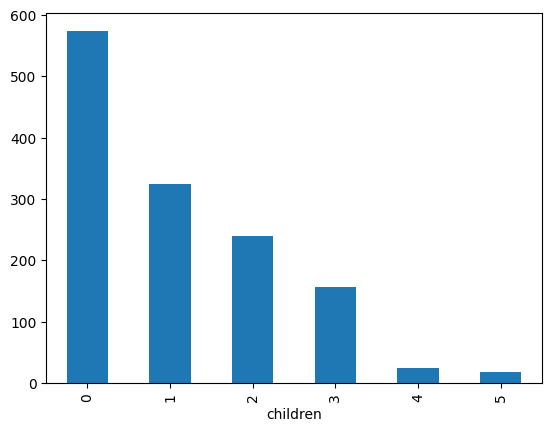

In [22]:
X["children"].value_counts().plot(kind='bar')

In [23]:
# Normalization - scale the data to be between 0 and 1

# Read in the insurance dataset
insurance = pd.read_csv(f"{path}/insurance.csv")

In [24]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [26]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler , OneHotEncoder

# Create a column transformer 
ct = make_column_transformer(
    (MinMaxScaler() , ["age" , "bmi" , "children"]), # turn these columns into a scale of 0 to 1
    (OneHotEncoder(handle_unknown='ignore') , ["sex" , "smoker" , "region"])
)

# Create X & y values
X = insurance.drop("charges" , axis=1)
y = insurance["charges"]

# Split the data 
X_train , X_test , y_train , y_test = train_test_split(X, y , test_size=0.2 , random_state=42)

# Fit the column transformer to the training data 
ct.fit(X_train)

# Transform training and test data with normalization (MinMaxScaler) and OneHotEncoder
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)


In [27]:
X_train.loc[0]

,0
age,19
sex,female
bmi,27.9
children,0
smoker,yes
region,southwest


In [28]:
X_train_normal[0]

array([0.60869565, 0.10734463, 0.4       , 1.        , 0.        ,
       1.        , 0.        , 0.        , 1.        , 0.        ,
       0.        ])

In [29]:
# Create the model 
insurance_model_normal = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the model 
insurance_model_normal.compile(
    loss = tf.keras.losses.mae,
    optimizer = tf.keras.optimizers.Adam(),
    metrics=["mae"]
)

# Fit the model 
insurance_model_normal.fit(X_train_normal , y_train , epochs=100)

Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 13296.7363 - mae: 13296.7363
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13288.3877 - mae: 13288.3877
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 13268.1494 - mae: 13268.1494
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13225.7842 - mae: 13225.7842
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13150.2686 - mae: 13150.2686
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 13030.7402 - mae: 13030.7402
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12856.8359 - mae: 12856.8359
Epoch 8/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12618.5410 - mae: 12618.5410
Epoch 9/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 12306.0967 - mae: 12306.0967
Epoch 10/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11913.2188 - mae: 11913.2188
Epoch 11/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 11447.0244 - mae: 11447.0244
Epoch 12/100
34/34 ━━━━━━━━━━━

In [30]:
# Evaluate our model trained on normalized data
insurance_model_normal.evaluate(X_test_normal , y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3516.8779 - mae: 3516.8779  


[3431.0078125, 3431.0078125]